In [ ]:
from aiopslab.orchestrator import Orchestrator  
from aiopslab.service.kubectl import KubeCtl  
from IPython.display import display

import importlib
import analyze.metrics
import analyze.traces
import analyze.logs
importlib.reload(analyze.metrics)
importlib.reload(analyze.traces)
importlib.reload(analyze.logs)


from analyze.pod import display_pods_status
from analyze.core import act, get_pod, extract_export_path, read_csv
from analyze.metrics import prepare_metric_context, inspect_service_metrics
from analyze.traces import (
    prepare_trace_context, 
    summarize_operation_durations, 
    plot_operation_duration_distributions,
    select_bad_traces, 
    analyze_bad_traces,
    inspect_top_bad_traces, 
)
from analyze.logs import prepare_log_context, inspect_service_logs

## Hotel Reservation: разбор инцидента `network_loss_hotel_res-detection-1`

В этом блоке разбираем сетевой инцидент в `Hotel Reservation` как SRE:
- запускаем сценарий `network_loss_hotel_res-detection-1`;
- фиксируем состояние namespace и pod'ов;
- собираем логи ключевых сервисов;
- смотрим сетевые и системные метрики для проблемного сервиса;
- анализируем трейсы и пользовательское воздействие;
- формируем краткое итоговое резюме.

Что именно делает fault:
- проблемный сервис: `user`;
- тип fault: `network_loss`;
- длительность fault в коде сценария: `200s`.

Ожидаемый эффект:
- pod `user` может оставаться `Running`, но межсервисное взаимодействие с ним должно деградировать;
- симптом будет виден скорее в latency, ошибках запросов, сетевых метриках и trace path, чем в pod status.


In [ ]:
network_loss_problem_id = "network_loss_hotel_res-detection-1"
namespace_nl = "test-hotel-reservation"
focus_services_nl = ["frontend", "user", "search", "profile", "recommendation", "reservation"]

orch_nl = Orchestrator()

class NetworkLossDummyAgent:
    async def get_action(self, state):
        return "get_traces('test-hotel-reservation', 5)"

orch_nl.register_agent(NetworkLossDummyAgent(), name="network-loss-research-agent")
kubectl_nl = KubeCtl()

In [ ]:
# Генерация инцидента

problem_desc_nl, instructs_nl, apis_nl = orch_nl.init_problem(network_loss_problem_id)

In [84]:
print(problem_desc_nl)
print("\n--- APIs ---")
for api in apis_nl:
    print(api)

You are an expert DevOps engineer assigned to detect anomalies in a deployed service.

Service Details:
Service Name: Hotel Reservation
Namespace: test-hotel-reservation
Description: A hotel reservation application built with Go and gRPC, providing backend in-memory and persistent databases, a recommender system for hotel recommendations, and a functionality to place reservations.
Supported Operations:
  - Get profile and rates of nearby hotels available during given time periods
  - Recommend hotels based on user provided metrics
  - Place reservations

You will begin by analyzing the service's state and telemetry, and then submit your solution:
1. str: "Yes" or "No" to indicate whether there are anomalies detected


--- APIs ---
exec_shell
get_logs
get_metrics
get_traces
read_metrics
read_traces
submit


In [ ]:
# Генерируем больше нагрузки
n = 5
for _ in range(n):
    orch_nl.session.problem.start_workload()

### Анализ подов

In [85]:
display_pods_status(namespace_nl, kubectl_nl)

,pod,ready,status,restarts,pod_ip,node
0,consul-b84877fb4-jnkc5,1/1,Running,0,10.244.1.41,kind-worker
1,frontend-69d95967fb-77724,1/1,Running,0,10.244.1.42,kind-worker
2,geo-99d8c58c-m8ccc,1/1,Running,1,10.244.1.43,kind-worker
3,jaeger-67445b6dd6-pfwlx,1/1,Running,0,10.244.1.44,kind-worker
4,memcached-profile-66bb9c8b9d-4zx7m,1/1,Running,0,10.244.1.45,kind-worker
5,memcached-rate-68585796cb-m6fh6,1/1,Running,0,10.244.1.48,kind-worker
6,memcached-reserve-646c7dcd6b-7gqgd,1/1,Running,0,10.244.1.53,kind-worker
7,mongodb-geo-5ff578bcb8-4vkm9,1/1,Running,0,10.244.1.46,kind-worker
8,mongodb-profile-758cb77f9f-sp69v,1/1,Running,0,10.244.1.58,kind-worker
9,mongodb-rate-56cc8659c9-lr7vw,1/1,Running,0,10.244.1.49,kind-worker


Поды живые, то есть:
- сервис Running
- нет CrashLoopBackOff
- нет явного падения процесса

### Метрики

Forwarding from 127.0.0.1:32000 -> 9090
Forwarding from [::1]:32000 -> 9090
Port forwarding established successfully.
Handling connection for 32000
Port forwarding stopped.
/Users/glebsolanik/work/r_m_r/sbertech/sre/experiments/benchmarks/notebooks/metrics_output/metric_20260311_134340
{'user': 'user-8477d787d8-4zwdn', 'search': 'search-65df96d8df-rnnqp', 'reservation': 'reservation-7699b8fdd4-w529g', 'profile': 'profile-676fcc86d5-t8z79', 'recommendation': 'recommendation-8675c6c9ff-zct6m', 'geo': 'geo-99d8c58c-m8ccc'}


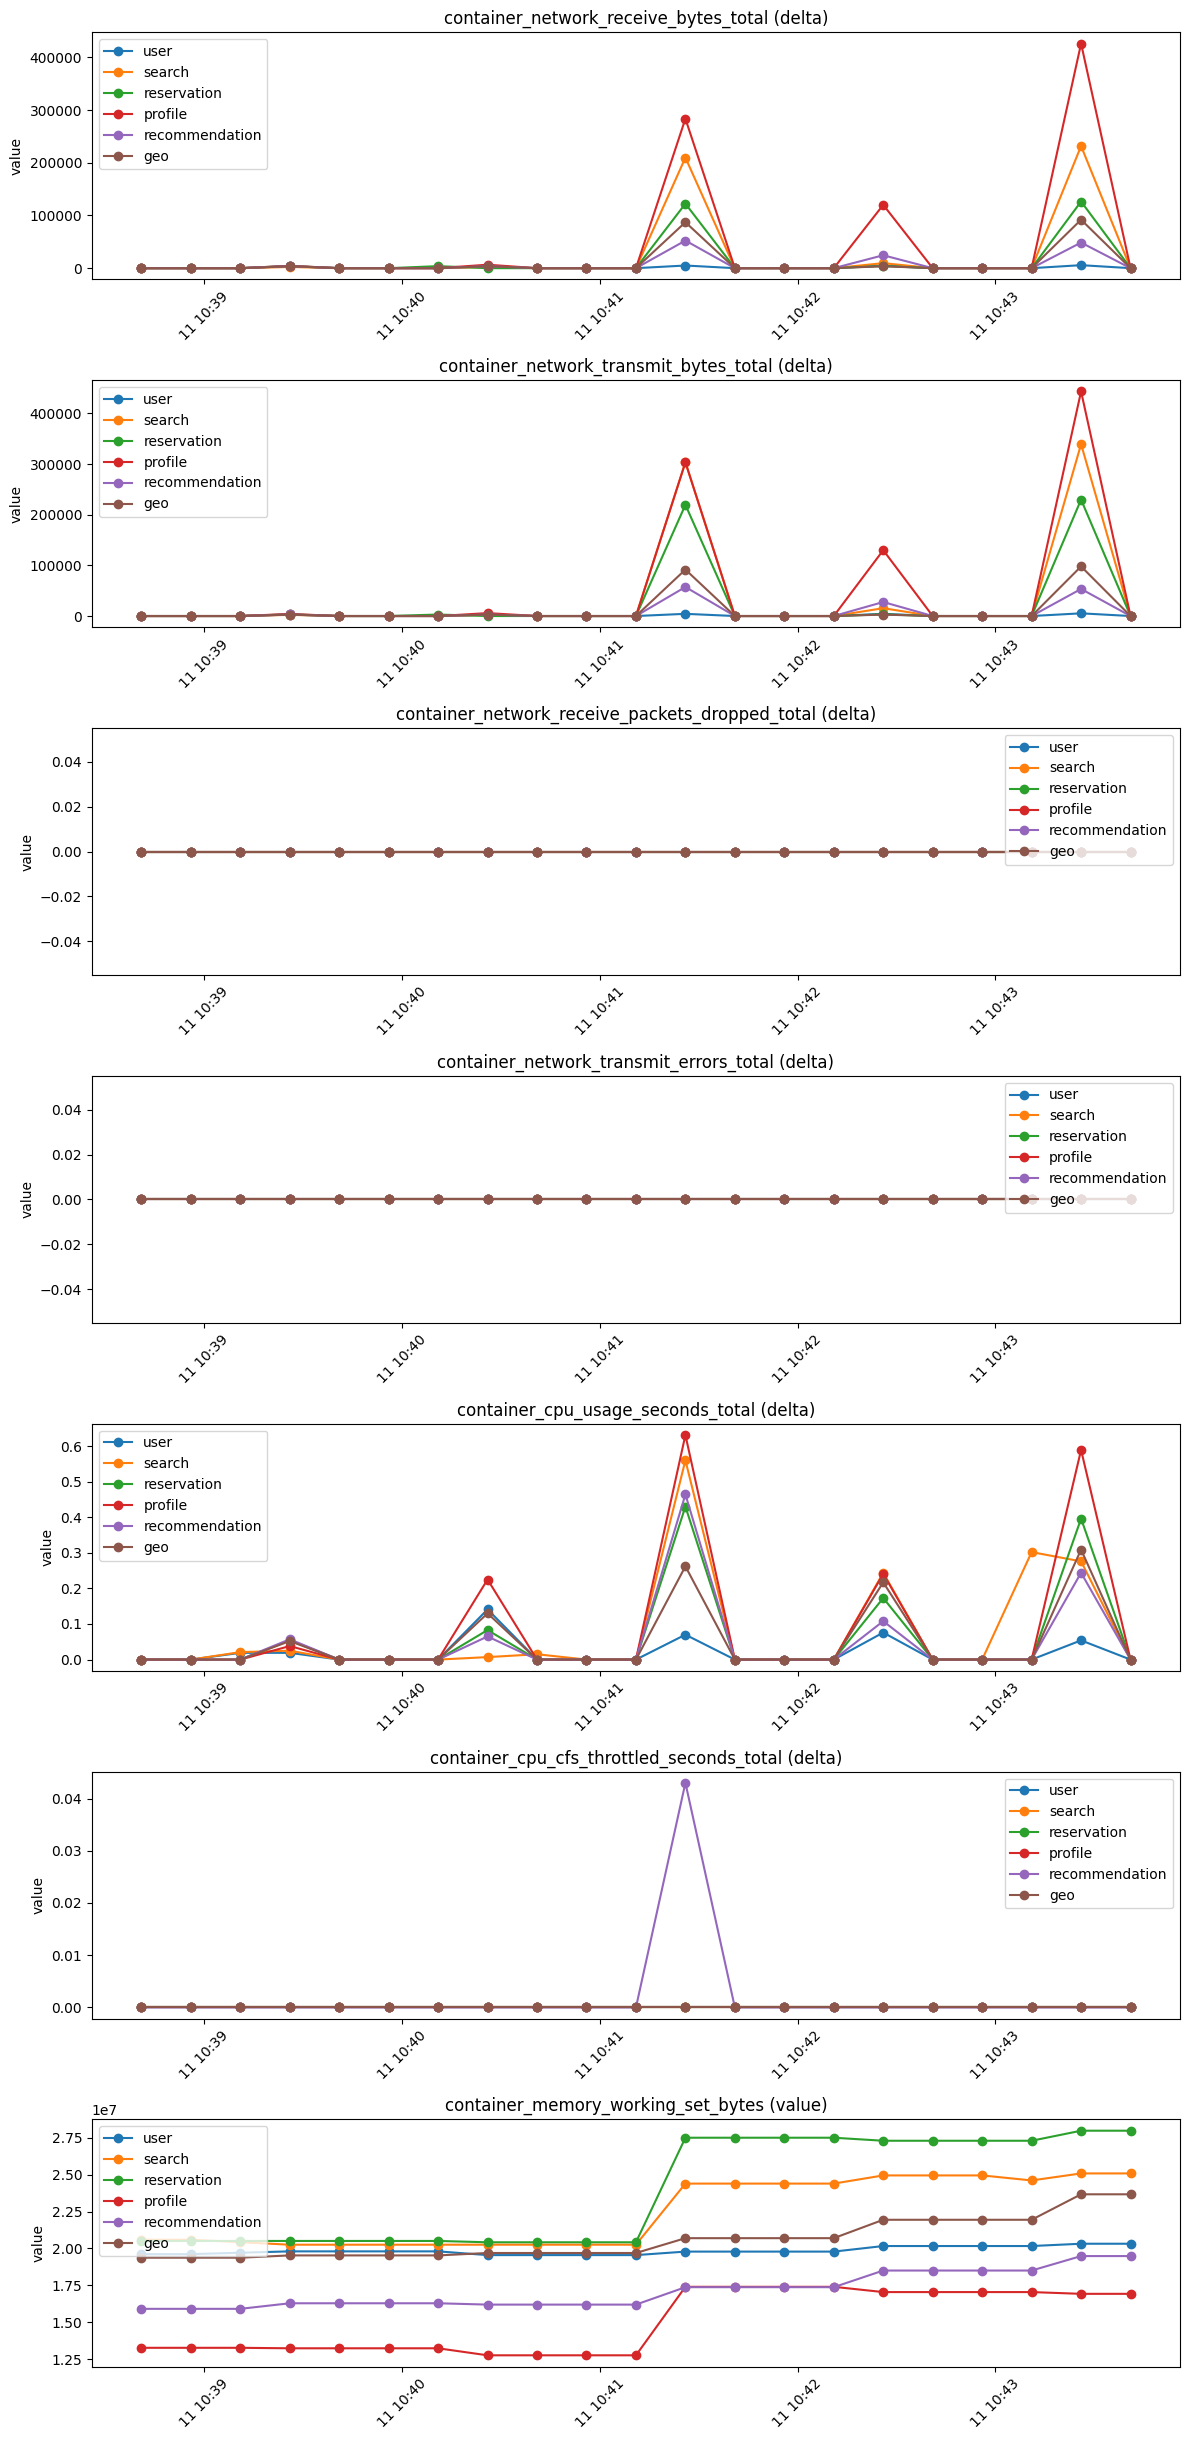

In [86]:
candidate_services_nl = ["user", "search", "reservation", "profile", "recommendation", "geo"]
candidate_metric_files_nl = [
    "kpi_container_network_receive_bytes_total.csv",
    "kpi_container_network_transmit_bytes_total.csv",
    "kpi_container_network_receive_packets_dropped_total.csv",
    "kpi_container_network_transmit_errors_total.csv",
    "kpi_container_cpu_usage_seconds_total.csv",
    "kpi_container_cpu_cfs_throttled_seconds_total.csv",
    "kpi_container_memory_working_set_bytes.csv",
]

metric_context_nl = prepare_metric_context(namespace_nl, candidate_services_nl, kubectl_nl, orch_nl)
print(metric_context_nl["metric_dir"])
print(metric_context_nl["pod_map"])

candidate_metric_summary_nl = inspect_service_metrics(
    metric_context_nl,
    candidate_services_nl,
    candidate_metric_files_nl,
    last_n=30,
)

По метрикам ресурсов все в порядке:
- CPU usage у всех сервисов низкий
- network_*_errors_total и network_receive_packets_dropped_total везде 0
- CPU throttling почти везде 0, у search только небольшие всплески, но не такого масштаба, чтобы объяснить сильную деградацию.
- Memory working set ровный, без роста и без намека на memory pressure / OOM
- По контейнерным network bytes видно, что трафик идет, но ничего аномального само по себе это не показывает.

То есть:
- ресурсная деградация не подтверждается
- сетевые ошибки на уровне этих container metrics не подтверждаются
- гипотеза CPU / memory / явный NIC error выглядит слабой

В итоге: по метрикам нельзя определить даже понимание в чем ошибка системы.

### Трейсы

In [ ]:
trace_context_nl = prepare_trace_context(namespace_nl, orch_nl)

In [88]:
# Статистика времени по операциям

op_stats = summarize_operation_durations(trace_context_nl)
display(op_stats)

,count,mean,p50,p95,p99,max
operation_name,,,,,,
/reservation.Reservation/MakeReservation,18,6.11,4.01,19.03,19.25,19.30
HTTP POST /reservation,9,7.37,4.92,17.19,19.63,20.24
HTTP GET /hotels,100,4.45,2.25,11.59,44.36,57.76
HTTP GET /recommendations,100,2.00,0.98,6.14,20.66,24.45
HTTP POST /user,2,3.80,3.80,5.88,6.06,6.11
/search.Search/Nearby,200,1.95,1.11,5.80,12.78,35.98
/user.User/CheckUser,22,0.82,0.46,2.63,5.37,6.08
/reservation.Reservation/CheckAvailability,200,0.86,0.33,2.35,7.94,35.31
/profile.Profile/GetProfiles,400,0.61,0.31,1.98,6.87,14.80


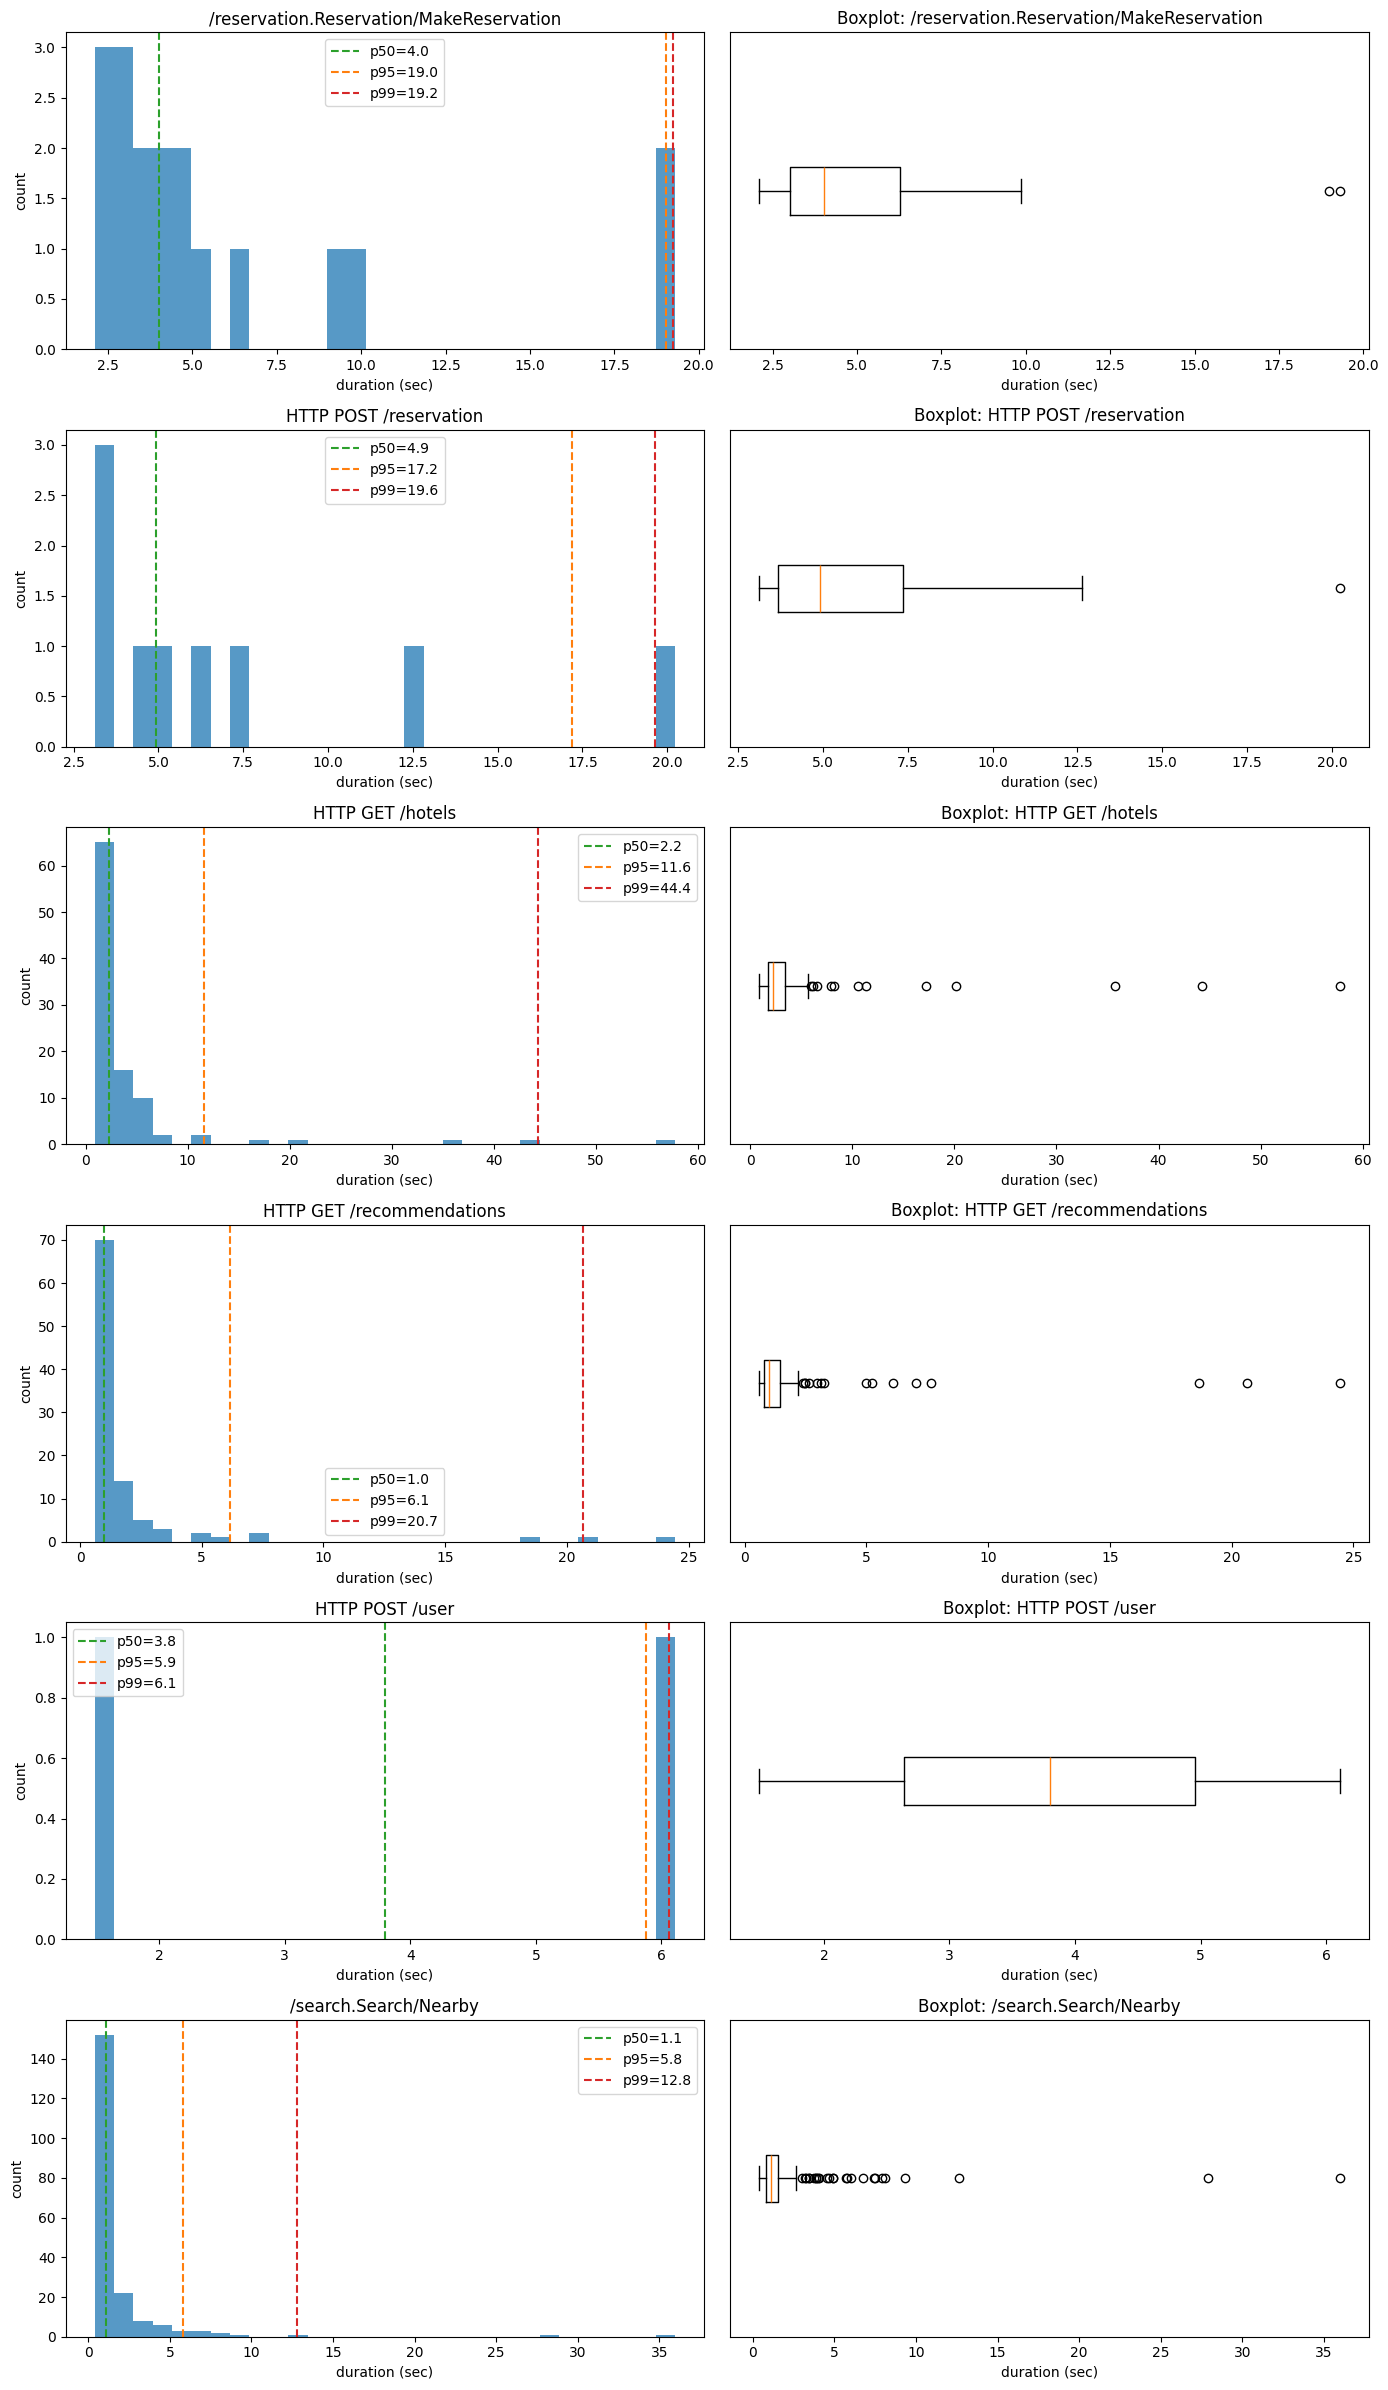

In [90]:
# Распределение времени по операциям

_ = plot_operation_duration_distributions(trace_context_nl, top_n=6)

Всего trace: 211
Bad traces: 12


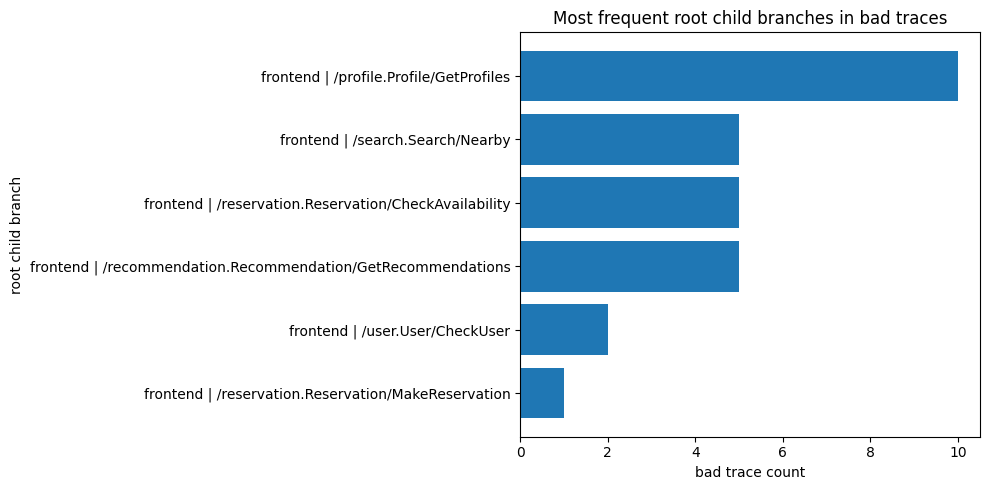

In [94]:
# Найдем плохие трейсы

# Получаем трейсы, в которых операции превышаю threshold 
# в 95 квантиль по времени исполнения
bad_trace_analysis = analyze_bad_traces(trace_context_nl, top_n=12, quantile=0.95)

In [95]:
# Анализ веток плохих трейсов
trees = inspect_top_bad_traces(trace_context_nl, bad_trace_analysis, top_n=12, max_depth=10)

Топ 12 плохих трейсов:


,trace_id,service_name,operation_name,duration,p95_threshold,has_error,response
220,60be50e2aeed7967,frontend,HTTP GET /hotels,57.764,11.59140,False,200
235,5f3526a6d6cfef95,frontend,HTTP GET /hotels,44.223,11.59140,False,200
205,26f303af023f24ba,frontend,HTTP GET /hotels,35.743,11.59140,False,200
1623,6e574743f49824d0,frontend,HTTP GET /recommendations,24.449,6.13575,False,200
1870,3954901fcf38339f,frontend,HTTP GET /recommendations,20.625,6.13575,False,200
6642,2915c13c1202cf2f,frontend,HTTP POST /reservation,20.237,17.19500,False,200
640,5885fd20f1a2eeb1,frontend,HTTP GET /hotels,20.196,11.59140,False,200
1829,1ab195fb99647cf0,frontend,HTTP GET /recommendations,18.682,6.13575,False,200
520,665db283d665827b,frontend,HTTP GET /hotels,17.204,11.59140,False,200
1629,361bb79093e0d0db,frontend,HTTP GET /recommendations,7.669,6.13575,False,200


Дерево трейса 60be50e2aeed7967


,depth,tree_label,duration,has_error,response,is_longest_root_child
0,0,frontend -> HTTP GET /hotels,57.764,False,200,False
1,1,frontend -> /search.Search/Nearby,7.449,False,Unknown,False
2,2,search -> /search.Search/Nearby,6.030,False,Unknown,False
3,3,search -> /geo.Geo/Nearby,2.465,False,Unknown,False
4,4,geo -> /geo.Geo/Nearby,0.040,False,Unknown,False
5,3,search -> /rate.Rate/GetRates,3.544,False,Unknown,False
6,4,rate -> /rate.Rate/GetRates,1.568,False,Unknown,False
7,5,rate -> memcached_get_multi_rate,1.514,False,Unknown,False
8,1,frontend -> /reservation.Reservation/CheckAv...,35.313,False,Unknown,True
9,2,reservation -> /reservation.Reservation/Ch...,22.913,False,Unknown,False


Дерево трейса 5f3526a6d6cfef95


...

,depth,tree_label,duration,has_error,response,is_longest_root_child
0,0,frontend -> HTTP GET /recommendations,7.669,False,200,False
1,1,frontend -> /recommendation.Recommendation/G...,1.667,False,Unknown,False
2,2,recommendation -> /recommendation.Recommen...,0.219,False,Unknown,False
3,1,frontend -> /profile.Profile/GetProfiles,5.793,False,Unknown,True
4,2,profile -> /profile.Profile/GetProfiles,0.984,False,Unknown,False
5,3,profile -> memcached_get_profile,0.890,False,Unknown,False


Дерево трейса 43cfab5ccb52ee35


,depth,tree_label,duration,has_error,response,is_longest_root_child
0,0,frontend -> HTTP GET /recommendations,7.043,False,200,False
1,1,frontend -> /recommendation.Recommendation/G...,2.468,False,Unknown,False
2,2,recommendation -> /recommendation.Recommen...,0.016,False,Unknown,False
3,1,frontend -> /profile.Profile/GetProfiles,4.406,False,Unknown,True
4,2,profile -> /profile.Profile/GetProfiles,3.177,False,Unknown,False
5,3,profile -> memcached_get_profile,3.095,False,Unknown,False


Дерево трейса 267aa2312d52d113


,depth,tree_label,duration,has_error,response,is_longest_root_child
0,0,frontend -> HTTP POST /user,6.110,False,200,False
1,1,frontend -> /user.User/CheckUser,6.081,False,Unknown,True
2,2,user -> /user.User/CheckUser,0.507,False,Unknown,False


### Логи

{"level":"info","time":"2026-03-11T09:25:43Z","message":"TLS disabled."}
{"level":"info","time":"2026-03-11T09:25:43Z","message":"Set global log level: info"}
{"level":"info","time":"2026-03-11T09:25:43Z","message":"Tune: setGCPercent to 100"}
2026-03-11T09:25:43Z INF cmd/search/main.go:24 > Reading config...
2026-03-11T09:25:43Z INF cmd/search/main.go:40 > Read target port: 8082
2026-03-11T09:25:43Z INF cmd/search/main.go:41 > Read consul address: consul:8500
2026-03-11T09:25:43Z INF cmd/search/main.go:42 > Read jaeger address: jaeger:6831
2026-03-11T09:25:43Z INF cmd/search/main.go:51 > Initializing jaeger agent [service name: search | host: jaeger:6831]...
2026-03-11T09:25:43Z INF tracing/tracer.go:26 > Jaeger client: adjusted sample ratio 1.000000
2026-03-11T09:25:43Z INF cmd/search/main.go:56 > Jaeger agent initialized
2026-03-11T09:25:43Z INF cmd/search/main.go:58 > Initializing consul agent [host: consul:8500]...
2026-03-11T09:25:43Z INF cmd/search/main.go:63 > Consul agent init

,service,line_count,error_like_count,error_like_sample,network_like_count,network_like_sample,retry_like_count,retry_like_sample
0,profile,24,0,,2,[90m2026-03-11T09:25:35Z[0m [32mINF[0m [1...,0,
1,reservation,23,0,,2,[90m2026-03-11T09:25:41Z[0m [32mINF[0m [1...,0,
2,search,15,0,,0,,0,


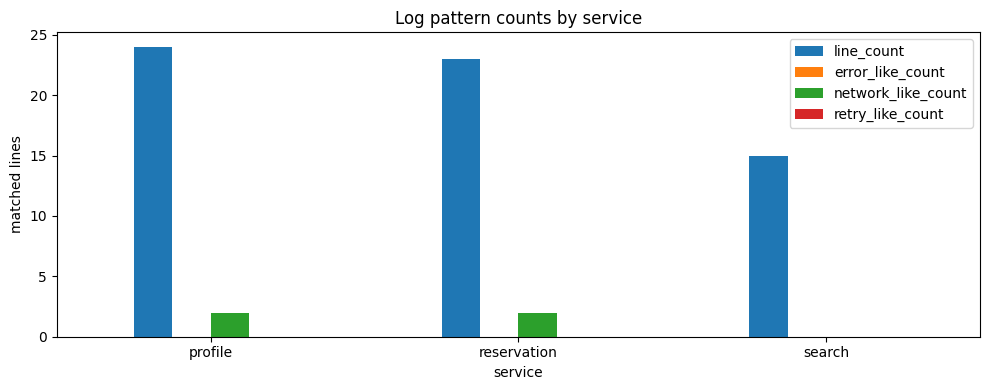


===== search =====
Нет совпадений

===== reservation =====
2026-03-11T09:25:41Z INF cmd/reservation/main.go:39 > Initializing DB connection...
2026-03-11T09:25:41Z INF tune/setting.go:61 > Tune: GetMemCTimeout 2

===== profile =====
2026-03-11T09:25:35Z INF cmd/profile/main.go:38 > Initializing DB connection...
2026-03-11T09:25:35Z INF tune/setting.go:61 > Tune: GetMemCTimeout 2


,service,line_count,error_like_count,error_like_sample,network_like_count,network_like_sample,retry_like_count,retry_like_sample
0,profile,24,0,,2,[90m2026-03-11T09:25:35Z[0m [32mINF[0m [1...,0,
1,reservation,23,0,,2,[90m2026-03-11T09:25:41Z[0m [32mINF[0m [1...,0,
2,search,15,0,,0,,0,


In [75]:
candidate_log_services_nl = ["search", "reservation", "profile"]
log_patterns_nl = {
    "error_like": r"error|panic|fail|failed|fatal|exception",
    "network_like": r"timeout|deadline|unavailable|refused|reset|connection|unreachable|broken pipe",
    "retry_like": r"retry|backoff|reconnect",
}

log_context_nl = prepare_log_context(namespace_nl, candidate_log_services_nl, orch_nl)

candidate_log_summary_nl = inspect_service_logs(
    log_context_nl,
    services=candidate_log_services_nl,
    regex_patterns=log_patterns_nl,
    line_pattern=r"error|panic|fail|failed|timeout|deadline|unavailable|refused|reset|connection|unreachable|retry|backoff",
    per_service_limit=20,
)

candidate_log_summary_nl

- логи не подтверждают гипотезу об ошибке в search/reservation/profile;
- явного сетевого фейла в логах этих сервисов не видно;
- traces пока информативнее, чем логи.

{"level":"info","time":"2026-03-11T09:25:44Z","message":"TLS disabled."}
{"level":"info","time":"2026-03-11T09:25:44Z","message":"Set global log level: info"}
{"level":"info","time":"2026-03-11T09:25:44Z","message":"Tune: setGCPercent to 100"}
2026-03-11T09:25:44Z INF cmd/user/main.go:24 > Reading config...
2026-03-11T09:25:44Z INF cmd/user/main.go:37 > Read database URL: mongodb-user:27017
2026-03-11T09:25:44Z INF cmd/user/main.go:38 > Initializing DB connection...
2026-03-11T09:25:44Z INF cmd/user/db.go:24 > New session successfull...
2026-03-11T09:25:44Z INF cmd/user/db.go:26 > Generating test data...
2026-03-11T09:25:44Z INF cmd/user/main.go:41 > Successfull
2026-03-11T09:25:44Z INF cmd/user/main.go:45 > Read target port: 8086
2026-03-11T09:25:44Z INF cmd/user/main.go:46 > Read consul address: consul:8500
2026-03-11T09:25:44Z INF cmd/user/main.go:47 > Read jaeger address: jaeger:6831
2026-03-11T09:25:44Z INF cmd/user/main.go:56 > Initializing jaeger agent [service name: user | host

,service,line_count,error_like_count,error_like_sample,network_like_count,network_like_sample,retry_like_count,retry_like_sample
0,user,20,0,,1,[90m2026-03-11T09:25:44Z[0m [32mINF[0m [1...,0,


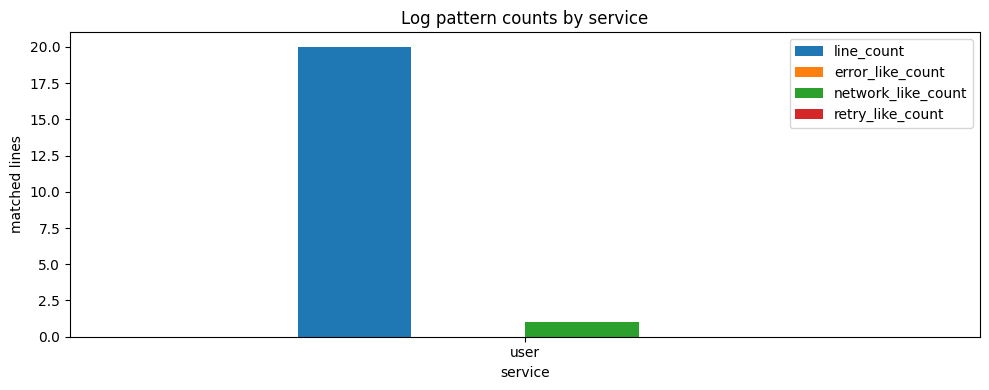


===== user =====
2026-03-11T09:25:44Z INF cmd/user/main.go:38 > Initializing DB connection...


,service,line_count,error_like_count,error_like_sample,network_like_count,network_like_sample,retry_like_count,retry_like_sample
0,user,20,0,,1,[90m2026-03-11T09:25:44Z[0m [32mINF[0m [1...,0,


In [77]:
candidate_log_services_nl = ["user"]
log_patterns_nl = {
    "error_like": r"error|panic|fail|failed|fatal|exception",
    "network_like": r"timeout|deadline|unavailable|refused|reset|connection|unreachable|broken pipe",
    "retry_like": r"retry|backoff|reconnect",
}

log_context_nl = prepare_log_context(namespace_nl, candidate_log_services_nl, orch_nl)

candidate_log_summary_nl = inspect_service_logs(
    log_context_nl,
    services=candidate_log_services_nl,
    regex_patterns=log_patterns_nl,
    line_pattern=r"error|panic|fail|failed|timeout|deadline|unavailable|refused|reset|connection|unreachable|retry|backoff",
    per_service_limit=20,
)

candidate_log_summary_nl